In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/rpw_clean.csv")

print(df.shape)

(197999, 42)


/var/folders/lc/jvqvfwdd1h3c9g5kg3l_96wh0000gp/T/ipykernel_1563/2435108683.py:1: DtypeWarning: Columns (36: note2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/rpw_clean.csv")


In [4]:
df[["cc1_fx_margin", "cc1_total_cost_pct"]].head()

,cc1_fx_margin,cc1_total_cost_pct
0,7.49,16.28
1,4.19,14.19
2,0.00,27.50
3,0.08,2.13
4,0.13,2.17


In [5]:
plot_df = df[
    ["cc1_fx_margin", "cc1_total_cost_pct"]
].dropna()

print(plot_df.shape)

(197982, 2)


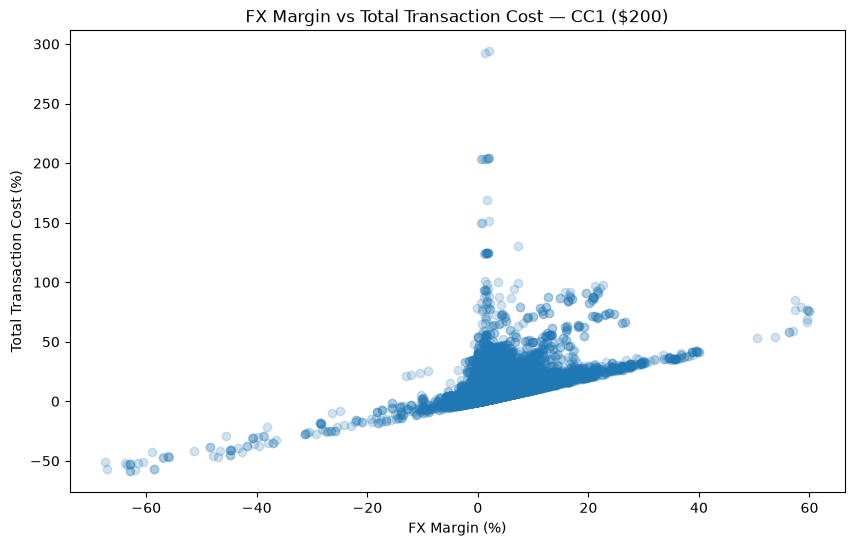

In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["cc1_fx_margin"],
    plot_df["cc1_total_cost_pct"],
    alpha=0.2
)

plt.xlabel("FX Margin (%)")
plt.ylabel("Total Transaction Cost (%)")
plt.title("FX Margin vs Total Transaction Cost — CC1 ($200)")

plt.show()

In [7]:
plot_df.describe()

,cc1_fx_margin,cc1_total_cost_pct
count,197982.000000,197982.000000
mean,2.122451,6.580295
std,2.829451,6.068858
min,-67.480000,-58.920000
25%,0.330000,3.130000
50%,1.470000,5.070000
75%,3.070000,8.190000
max,59.980000,293.720000


In [8]:
print("Negative FX margins:", (plot_df["cc1_fx_margin"] < 0).sum())
print("Negative total costs:", (plot_df["cc1_total_cost_pct"] < 0).sum())
print("Total costs above 20%:", (plot_df["cc1_total_cost_pct"] > 20).sum())
print("Total costs above 50%:", (plot_df["cc1_total_cost_pct"] > 50).sum())

Negative FX margins: 8827
Negative total costs: 1241
Total costs above 20%: 6084
Total costs above 50%: 251


In [9]:
high_cost = df[
    df["cc1_total_cost_pct"] > 50
][[
    "corridor",
    "source_name",
    "destination_name",
    "firm",
    "cc1_fx_margin",
    "cc1_total_cost_pct"
]]

print(high_cost.shape)
high_cost.head(20)

(251, 6)


,corridor,source_name,destination_name,firm,cc1_fx_margin,cc1_total_cost_pct
51762,DEUTGO,Germany,Togo,Azimo,53.77,53.77
64858,TZAKEN,Tanzania,Kenya,National Bank of Commerce Ltd (NBC),8.49,50.49
70055,TZAKEN,Tanzania,Kenya,National Bank of Commerce Ltd (NBC),8.92,50.92
74991,TZAKEN,Tanzania,Kenya,National Bank of Commerce Ltd (NBC),8.57,50.57
75003,TZAUGA,Tanzania,Uganda,National Bank of Commerce Ltd (NBC),12.37,54.37
79912,TZAKEN,Tanzania,Kenya,National Bank of Commerce Ltd (NBC),9.26,51.26
79918,TZARWA,Tanzania,Rwanda,NMB (National Microfinance Bank),11.43,50.43
84803,TZAKEN,Tanzania,Kenya,National Bank of Commerce Ltd (NBC),9.24,51.24
84809,TZARWA,Tanzania,Rwanda,NMB (National Microfinance Bank),11.29,50.29
90751,TZAKEN,Tanzania,Kenya,National Bank of Commerce Ltd (NBC),9.91,71.20


In [10]:
high_cost_corridors = (
    df.groupby("corridor")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median")
    )
    .query("observations >= 100")
    .sort_values("average_cost", ascending=False)
)

high_cost_corridors.head(15)

,observations,average_cost,median_cost
corridor,,,
TURBGR,415,30.452964,13.100
TZAUGA,347,28.057435,26.160
TZAKEN,330,26.639212,15.000
TZARWA,305,21.224918,13.370
ZAFCHN,298,19.247852,16.780
ZAFAGO,359,19.109638,18.340
ZAFSWZ,255,17.169373,17.520
ZAFBWA,578,17.059481,13.530
ZAFNGA,490,15.633959,14.005


In [11]:
turbgr = (
    df[df["corridor"] == "TURBGR"]
    [["firm", "cc1_fx_margin", "cc1_total_cost_pct"]]
    .dropna()
    .sort_values("cc1_total_cost_pct", ascending=False)
)

turbgr.head(20)

,firm,cc1_fx_margin,cc1_total_cost_pct
195639,Denizbank,1.97,293.72
195638,Turkey IS Bank,1.26,292.49
175342,Turkey IS Bank,2.05,204.68
188953,Denizbank,1.83,203.94
175343,Denizbank,1.81,203.92
188952,Turkey IS Bank,1.23,203.86
179511,Denizbank,1.71,203.82
179510,Turkey IS Bank,0.75,203.38
167620,Turkey IS Bank,0.63,203.26
195640,Yapı ve Kredi Bankası,1.74,168.82


In [12]:
turbgr_extreme = (
    df[
        (df["corridor"] == "TURBGR") &
        (df["cc1_total_cost_pct"] > 100)
    ][[
        "firm",
        "cc1_lcu_amount",
        "cc1_lcu_code",
        "cc1_lcu_fee",
        "cc1_lcu_fx_rate",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]]
    .sort_values("cc1_total_cost_pct", ascending=False)
)

turbgr_extreme

,firm,cc1_lcu_amount,cc1_lcu_code,cc1_lcu_fee,cc1_lcu_fx_rate,cc1_fx_margin,cc1_total_cost_pct
195639,Denizbank,570.0,TRY,1663.00,0.02700,1.97,293.72
195638,Turkey IS Bank,570.0,TRY,1660.00,0.02720,1.26,292.49
175342,Turkey IS Bank,570.0,TRY,1155.00,0.03050,2.05,204.68
188953,Denizbank,570.0,TRY,1152.00,0.02840,1.83,203.94
175343,Denizbank,570.0,TRY,1152.00,0.03050,1.81,203.92
188952,Turkey IS Bank,570.0,TRY,1155.00,0.02860,1.23,203.86
179511,Denizbank,570.0,TRY,1152.00,0.02900,1.71,203.82
179510,Turkey IS Bank,570.0,TRY,1155.00,0.02930,0.75,203.38
167620,Turkey IS Bank,570.0,TRY,1155.00,0.03200,0.63,203.26
195640,Yapı ve Kredi Bankası,570.0,TRY,952.38,0.02710,1.74,168.82


In [13]:
turbgr_extreme = (
    df[
        (df["corridor"] == "TURBGR") &
        (df["cc1_total_cost_pct"] > 100)
    ][[
        "date",
        "period",
        "firm",
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]]
    .sort_values("date")
)

turbgr_extreme

,date,period,firm,cc1_lcu_amount,cc1_lcu_fee,cc1_fx_margin,cc1_total_cost_pct
138754,2023-02-23,2023_1Q,Turkey IS Bank,570.0,700.00,1.09,123.90
141771,2023-05-22,2023_2Q,Turkey IS Bank,570.0,700.00,7.32,130.13
148899,2023-08-22,2023_3Q,Turkey IS Bank,570.0,700.00,1.81,124.62
148900,2023-08-22,2023_3Q,Denizbank,570.0,700.00,1.78,124.59
158032,2023-11-23,2023_4Q,Denizbank,570.0,700.00,1.51,124.32
158852,2023-11-27,2023_4Q,Turkey IS Bank,570.0,700.00,1.44,124.25
164076,2024-02-19,2024_1Q,Denizbank,570.0,700.00,1.72,124.53
164077,2024-02-19,2024_1Q,Yapi ve Kredi Bankasi,570.0,700.00,1.59,124.40
167620,2024-02-23,2024_1Q,Turkey IS Bank,570.0,1155.00,0.63,203.26
167812,2024-02-23,2024_1Q,Turkey IS Bank,570.0,850.00,0.63,149.75


In [14]:
turbgr_extreme = (
    df[
        (df["corridor"] == "TURBGR") &
        (df["cc1_total_cost_pct"] > 100)
    ][[
        "date",
        "firm",
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]]
    .copy()
)

turbgr_extreme["fee_pct_of_amount"] = (
    turbgr_extreme["cc1_lcu_fee"]
    / turbgr_extreme["cc1_lcu_amount"]
    * 100
)

turbgr_extreme["cost_minus_fee_pct"] = (
    turbgr_extreme["cc1_total_cost_pct"]
    - turbgr_extreme["fee_pct_of_amount"]
)

turbgr_extreme.sort_values(
    "cc1_total_cost_pct",
    ascending=False
)

,date,firm,cc1_lcu_amount,cc1_lcu_fee,cc1_fx_margin,cc1_total_cost_pct,fee_pct_of_amount,cost_minus_fee_pct
195639,2025-02-19,Denizbank,570.0,1663.00,1.97,293.72,291.754386,1.965614
195638,2025-02-19,Turkey IS Bank,570.0,1660.00,1.26,292.49,291.228070,1.261930
175342,2024-05-22,Turkey IS Bank,570.0,1155.00,2.05,204.68,202.631579,2.048421
188953,2024-11-19,Denizbank,570.0,1152.00,1.83,203.94,202.105263,1.834737
175343,2024-05-22,Denizbank,570.0,1152.00,1.81,203.92,202.105263,1.814737
188952,2024-11-19,Turkey IS Bank,570.0,1155.00,1.23,203.86,202.631579,1.228421
179511,2024-08-21,Denizbank,570.0,1152.00,1.71,203.82,202.105263,1.714737
179510,2024-08-21,Turkey IS Bank,570.0,1155.00,0.75,203.38,202.631579,0.748421
167620,2024-02-23,Turkey IS Bank,570.0,1155.00,0.63,203.26,202.631579,0.628421
195640,2025-02-19,Yapı ve Kredi Bankası,570.0,952.38,1.74,168.82,167.084211,1.735789


In [15]:
extreme_costs = (
    df[df["cc1_total_cost_pct"] > 50]
    .groupby("corridor")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        avg_total_cost=("cc1_total_cost_pct", "mean"),
        avg_fx_margin=("cc1_fx_margin", "mean"),
        avg_fee_pct=(
            "cc1_lcu_fee",
            lambda x: (
                x / df.loc[x.index, "cc1_lcu_amount"] * 100
            ).mean()
        )
    )
    .sort_values("observations", ascending=False)
)

extreme_costs.head(15)

,observations,avg_total_cost,avg_fx_margin,avg_fee_pct
corridor,,,,
TZAKEN,69,69.746377,15.847101,53.899170
TURBGR,65,110.428154,2.043692,108.383995
TZAUGA,51,69.939020,10.301765,59.637300
TZARWA,30,66.427000,17.212667,49.214444
ZAFMWI,16,67.262003,45.813125,21.447947
ZAFAGO,2,55.740000,1.430000,54.306569
ZAFMOZ,2,55.740000,1.430000,54.306569
ZAFZMB,2,56.540000,2.230000,54.306569
ZAFSWZ,2,54.310000,0.000000,54.306569


In [16]:
extreme_costs_reliable = (
    extreme_costs[
        extreme_costs["observations"] >= 20
    ]
    .sort_values("avg_total_cost", ascending=False)
)

extreme_costs_reliable

,observations,avg_total_cost,avg_fx_margin,avg_fee_pct
corridor,,,,
TURBGR,65,110.428154,2.043692,108.383995
TZAUGA,51,69.939020,10.301765,59.637300
TZAKEN,69,69.746377,15.847101,53.899170
TZARWA,30,66.427000,17.212667,49.214444


In [17]:
extreme_share = (
    df.groupby("corridor")
    .agg(
        total_observations=("cc1_total_cost_pct", "count"),
        extreme_observations=(
            "cc1_total_cost_pct",
            lambda x: (x > 50).sum()
        )
    )
)

extreme_share["extreme_pct"] = (
    extreme_share["extreme_observations"]
    / extreme_share["total_observations"]
    * 100
)

extreme_share = (
    extreme_share[
        extreme_share["extreme_observations"] >= 20
    ]
    .sort_values("extreme_pct", ascending=False)
)

extreme_share.head(15)

,total_observations,extreme_observations,extreme_pct
corridor,,,
TZAKEN,330,69,20.909091
TURBGR,415,65,15.662651
TZAUGA,347,51,14.697406
TZARWA,305,30,9.836066


In [18]:
extreme_provider = (
    df[df["cc1_total_cost_pct"] > 50]
    .groupby("firm")
    .agg(
        extreme_observations=("cc1_total_cost_pct", "count"),
        avg_total_cost=("cc1_total_cost_pct", "mean"),
        avg_fx_margin=("cc1_fx_margin", "mean")
    )
    .sort_values("extreme_observations", ascending=False)
)

extreme_provider.head(15)

,extreme_observations,avg_total_cost,avg_fx_margin
firm,,,
National Bank of Commerce Ltd (NBC),58,68.861207,11.407931
NMB (National Microfinance Bank),33,66.577879,16.204848
Turkey IS Bank,25,123.968800,1.659200
Stanbic Bank,24,77.687500,16.779167
First National Bank of South Africa,23,57.966769,10.099565
KCB Bank,18,59.613333,16.615556
Ziraat Bank,11,74.298182,2.120000
Denizbank,9,162.476667,2.260000
Yapi ve Kredi Bankasi,8,104.592500,2.127500


In [20]:
provider_extreme_share = (
    df.groupby("firm")
    .agg(
        total_observations=("cc1_total_cost_pct", "count"),
        extreme_observations=(
            "cc1_total_cost_pct",
            lambda x: (x > 50).sum()
        )
    )
)

provider_extreme_share["extreme_pct"] = (
    provider_extreme_share["extreme_observations"]
    / provider_extreme_share["total_observations"]
    * 100
)

provider_extreme_share = (
    provider_extreme_share[
        provider_extreme_share["extreme_observations"] >= 5
    ]
    .sort_values("extreme_pct", ascending=False)
)

provider_extreme_share.head(20)

,total_observations,extreme_observations,extreme_pct
firm,,,
National Bank of Commerce Ltd (NBC),99,58,58.585859
Turkey IS Bank,68,25,36.764706
NMB (National Microfinance Bank),94,33,35.106383
Ziraat Bank,36,11,30.555556
Yapi ve Kredi Bankasi,29,8,27.586207
Denizbank,36,9,25.000000
Stanbic Bank,118,24,20.338983
KCB Bank,174,18,10.344828
First National Bank of South Africa,623,23,3.691814


In [22]:
provider_corridor_extreme = (
    df[df["cc1_total_cost_pct"] > 50]
    .groupby(["corridor", "firm"])
    .agg(
        extreme_observations=("cc1_total_cost_pct", "count"),
        avg_total_cost=("cc1_total_cost_pct", "mean"),
        avg_fx_margin=("cc1_fx_margin", "mean")
    )
    .query("extreme_observations >= 5")
    .sort_values(
        ["extreme_observations", "avg_total_cost"],
        ascending=False
    )
)

provider_corridor_extreme.head(20)

extreme_observations  \
corridor firm                                                        
TZAKEN   National Bank of Commerce Ltd (NBC)                    36   
TURBGR   Turkey IS Bank                                         25   
TZAUGA   National Bank of Commerce Ltd (NBC)                    22   
TZARWA   NMB (National Microfinance Bank)                       21   
TZAKEN   Stanbic Bank                                           14   
         KCB Bank                                               14   
TZAUGA   NMB (National Microfinance Bank)                       12   
TURBGR   Ziraat Bank                                            11   
TZAUGA   Stanbic Bank                                           10   
TURBGR   Denizbank                                               9   
         Yapi ve Kredi Bankasi                                   8   
ZAFMWI   First National Bank of South Africa                     7   
TURBGR   Western Union                                           5   

                                              avg_total_cost  avg_fx_margin  
corridor firm                                                                
TZAKEN   National Bank of Commerce Ltd (NBC)       68.331111      12.733056  
TURBGR   Turkey IS Bank                           123.968800       1.659200  
TZAUGA   National Bank of Commerce Ltd (NBC)       69.728636       9.239545  
TZARWA   NMB (National Microfinance Bank)          65.436190      16.900476  
TZAKEN   Stanbic Bank                              80.151429      22.310000  
         KCB Bank                                  61.014286      17.281429  
TZAUGA   NMB (National Microfinance Bank)          68.575833      14.987500  
TURBGR   Ziraat Bank                               74.298182       2.120000  
TZAUGA   Stanbic Bank                              74.238000       9.036000  
TURBGR   Denizbank                                162.476667       2.260000  
         Yapi ve Kredi Bankasi                    104.592500       2.127500  
ZAFMWI   First National Bank of South Africa       63.216528      30.075714  
TURBGR   Western Union                             71.540000       4.164000

In [23]:
provider_corridor_extreme.head(20).reset_index()

,corridor,firm,extreme_observations,avg_total_cost,avg_fx_margin
0,TZAKEN,National Bank of Commerce Ltd (NBC),36,68.331111,12.733056
1,TURBGR,Turkey IS Bank,25,123.968800,1.659200
2,TZAUGA,National Bank of Commerce Ltd (NBC),22,69.728636,9.239545
3,TZARWA,NMB (National Microfinance Bank),21,65.436190,16.900476
4,TZAKEN,Stanbic Bank,14,80.151429,22.310000
5,TZAKEN,KCB Bank,14,61.014286,17.281429
6,TZAUGA,NMB (National Microfinance Bank),12,68.575833,14.987500
7,TURBGR,Ziraat Bank,11,74.298182,2.120000
8,TZAUGA,Stanbic Bank,10,74.238000,9.036000
9,TURBGR,Denizbank,9,162.476667,2.260000


In [25]:
cost_distribution = df["cc1_total_cost_pct"].dropna()

cost_distribution.describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    197982.000000
mean          6.580295
std           6.068858
min         -58.920000
1%            0.000000
5%            1.170000
10%           1.900000
25%           3.130000
50%           5.070000
75%           8.190000
90%          12.890000
95%          17.310000
99%          27.991900
max         293.720000
Name: cc1_total_cost_pct, dtype: float64

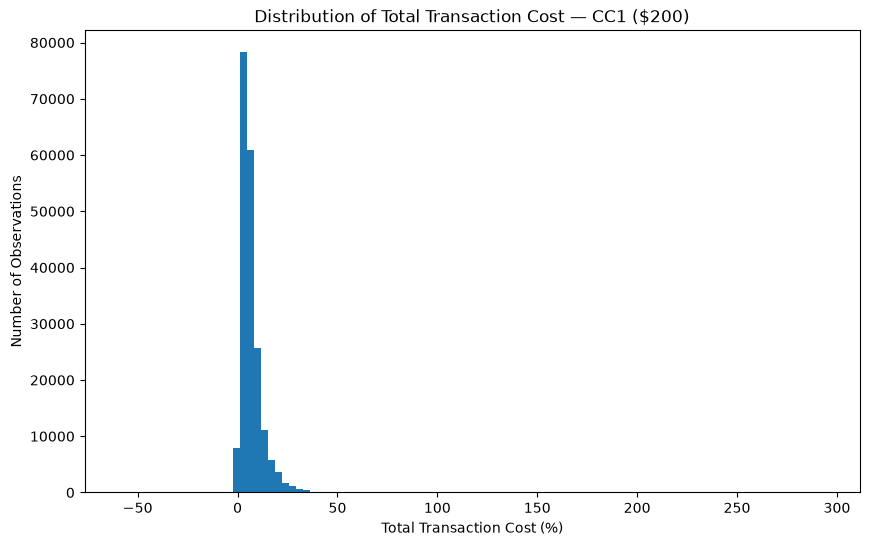

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    cost_distribution,
    bins=100
)

plt.xlabel("Total Transaction Cost (%)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Total Transaction Cost — CC1 ($200)")

plt.show()

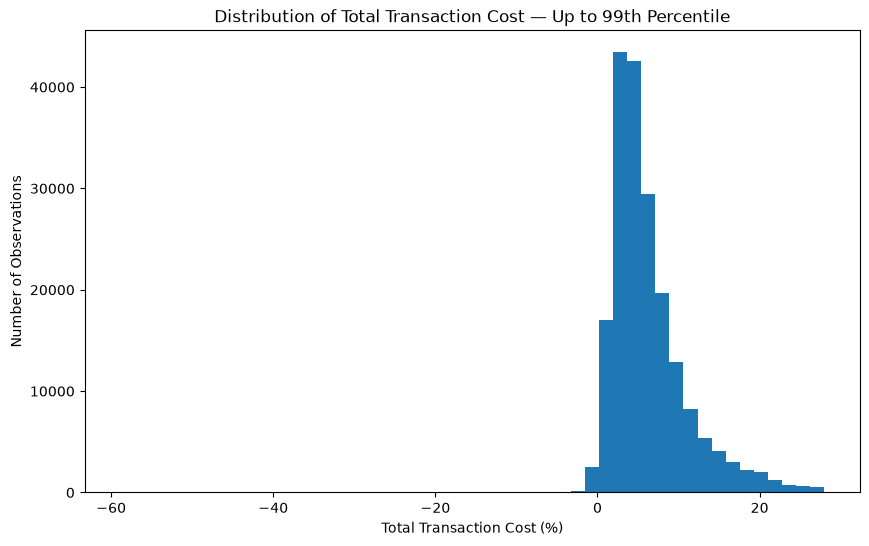

In [27]:
plt.figure(figsize=(10, 6))

plt.hist(
    cost_distribution[cost_distribution <= cost_distribution.quantile(0.99)],
    bins=50
)

plt.xlabel("Total Transaction Cost (%)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Total Transaction Cost — Up to 99th Percentile")

plt.show()

In [28]:
negative_costs = (
    df[df["cc1_total_cost_pct"] < 0]
    [[
        "corridor",
        "firm",
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_lcu_fx_rate",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]]
    .sort_values("cc1_total_cost_pct")
)

negative_costs.head(20)

,corridor,firm,cc1_lcu_amount,cc1_lcu_fee,cc1_lcu_fx_rate,cc1_fx_margin,cc1_total_cost_pct
129763,DEUNGA,ATL Money Transfer,140.0,5.60,750.000000,-62.92,-58.92
129764,DEUNGA,ATL Money Transfer,140.0,5.60,750.000000,-62.92,-58.92
190916,ZAFMWI,EcoCash Remit,1370.0,61.65,155.288200,-61.95,-57.45
187552,ZAFMWI,Mukuru,1370.0,137.00,160.526200,-67.04,-57.04
189415,ZAFMWI,Mama Money,1370.0,25.00,151.975684,-58.50,-56.68
189414,ZAFMWI,Mama Money,1370.0,25.00,151.975684,-58.50,-56.68
189260,ZAFMWI,Hello-Paisa,1370.0,137.00,156.679000,-63.49,-53.49
189259,ZAFMWI,Hello-Paisa,1370.0,137.00,156.554000,-62.89,-52.89
187554,ZAFMWI,Mukuru,1370.0,137.00,155.801100,-62.85,-52.85
187553,ZAFMWI,Mukuru,1370.0,137.00,155.791500,-62.84,-52.84


In [29]:
negative_by_corridor = (
    df[df["cc1_total_cost_pct"] < 0]
    .groupby("corridor")
    .agg(
        negative_observations=("cc1_total_cost_pct", "count"),
        average_negative_cost=("cc1_total_cost_pct", "mean"),
        minimum_cost=("cc1_total_cost_pct", "min")
    )
    .sort_values("negative_observations", ascending=False)
)

negative_by_corridor.head(15)

,negative_observations,average_negative_cost,minimum_cost
corridor,,,
ZAFMWI,106,-18.664906,-57.45
AREPAK,40,-0.196250,-0.59
KWTPAK,38,-0.741842,-3.21
GBRTZA,34,-2.284412,-11.79
GBRPAK,33,-0.306364,-1.12
DEUNGA,25,-22.077600,-58.92
GBRKEN,24,-1.185417,-3.47
ITABGD,23,-0.886522,-4.12
AUSPAK,23,-0.440000,-1.51


In [31]:
negative_count = (cost_distribution < 0).sum()
strong_negative_count = (cost_distribution < -5).sum()

print("Negative observations:", negative_count)
print("Negative percentage:", negative_count / len(cost_distribution) * 100)

print("Strongly negative observations (< -5%):", strong_negative_count)
print(
    "Strongly negative percentage:",
    strong_negative_count / len(cost_distribution) * 100
)

Negative observations: 1241
Negative percentage: 0.626824660827752
Strongly negative observations (< -5%): 165
Strongly negative percentage: 0.08334090977967694


In [32]:
comparison = df[
    ["cc1_total_cost_pct", "cc2_total_cost_pct"]
].dropna()

print(comparison.shape)

print(
    comparison[
        ["cc1_total_cost_pct", "cc2_total_cost_pct"]
    ].describe()
)

(196944, 2)
       cc1_total_cost_pct  cc2_total_cost_pct
count       196944.000000       196944.000000
mean             6.591298            4.364463
std              6.074867            3.774703
min            -58.920000          -60.810000
25%              3.130000            1.960000
50%              5.070000            3.430000
75%              8.210000            5.910000
max            293.720000          120.760000


In [33]:
comparison["cost_difference"] = (
    comparison["cc1_total_cost_pct"]
    - comparison["cc2_total_cost_pct"]
)

print(comparison["cost_difference"].describe())

print(
    "Average reduction:",
    comparison["cost_difference"].mean()
)

print(
    "Median reduction:",
    comparison["cost_difference"].median()
)

count    196944.000000
mean          2.226835
std           3.149123
min         -16.980000
25%           0.810000
50%           1.500000
75%           2.450000
max         172.960000
Name: cost_difference, dtype: float64
Average reduction: 2.226834771150951
Median reduction: 1.4999999999999998


In [34]:
corridor_reduction = (
    df[
        [
            "corridor",
            "cc1_total_cost_pct",
            "cc2_total_cost_pct"
        ]
    ]
    .dropna()
    .assign(
        cost_reduction=lambda x:
            x["cc1_total_cost_pct"] - x["cc2_total_cost_pct"]
    )
    .groupby("corridor")
    .agg(
        observations=("cost_reduction", "count"),
        average_reduction=("cost_reduction", "mean"),
        median_reduction=("cost_reduction", "median")
    )
    .query("observations >= 100")
    .sort_values("average_reduction", ascending=False)
)

corridor_reduction.head(15)

,observations,average_reduction,median_reduction
corridor,,,
TURBGR,415,16.065807,5.720
TZAUGA,347,13.612911,14.990
TZAKEN,330,11.352394,3.485
ZAFSWZ,255,9.919608,10.480
ZAFAGO,358,9.736983,9.460
TZARWA,305,8.508033,2.260
ZAFCHN,298,8.465268,6.870
ZAFLSO,307,8.318827,7.790
PAKAFG,154,7.122403,7.315


In [35]:
print(
    "Observations where $500 cost is higher:",
    (comparison["cost_difference"] < 0).sum()
)

print(
    "Percentage:",
    (comparison["cost_difference"] < 0).mean() * 100
)

Observations where $500 cost is higher: 3481
Percentage: 1.7675075148265496


In [36]:
fee_fx = df[
    [
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]
].dropna().copy()

fee_fx["fee_pct"] = (
    fee_fx["cc1_lcu_fee"]
    / fee_fx["cc1_lcu_amount"]
    * 100
)

fee_fx["reconstructed_cost"] = (
    fee_fx["fee_pct"]
    + fee_fx["cc1_fx_margin"]
)

print(fee_fx.head())

   cc1_lcu_amount  cc1_lcu_fee  cc1_fx_margin  cc1_total_cost_pct    fee_pct  \
0         33000.0       2900.0           7.49               16.28   8.787879   
1         33000.0       3300.0           4.19               14.19  10.000000   
2         33000.0       9075.0           0.00               27.50  27.500000   
3           735.0         15.0           0.08                2.13   2.040816   
4           735.0         15.0           0.13                2.17   2.040816   

   reconstructed_cost  
0           16.277879  
1           14.190000  
2           27.500000  
3            2.120816  
4            2.170816  


In [37]:
print(
    fee_fx[
        ["fee_pct", "cc1_fx_margin", "cc1_total_cost_pct"]
    ].describe()
)

             fee_pct  cc1_fx_margin  cc1_total_cost_pct
count  197976.000000  197976.000000       197976.000000
mean        4.457564       2.122515            6.580443
std         5.264396       2.829469            6.068891
min         0.000000     -67.480000          -58.920000
25%         1.950000       0.330000            3.130000
50%         3.000000       1.470000            5.070000
75%         5.000000       3.070000            8.190000
max       291.754386      59.980000          293.720000


In [38]:
fee_fx["reconstruction_error"] = (
    fee_fx["cc1_total_cost_pct"]
    - fee_fx["reconstructed_cost"]
)

print(fee_fx["reconstruction_error"].describe())

count    197976.000000
mean          0.000363
std           0.075274
min         -23.320000
25%          -0.001429
50%           0.000000
75%           0.002857
max           7.756667
Name: reconstruction_error, dtype: float64


In [40]:
large_errors = (
    fee_fx[
        fee_fx["reconstruction_error"].abs() > 1
    ]
    [[
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct",
        "fee_pct",
        "reconstructed_cost",
        "reconstruction_error"
    ]]
    .sort_values("reconstruction_error")
)

print(large_errors.shape)
print(large_errors.head(20))

(29, 7)
       cc1_lcu_amount  cc1_lcu_fee  cc1_fx_margin  cc1_total_cost_pct  \
16557           140.0        39.55           0.00                4.93   
46695           200.0        30.00           0.00                1.00   
732           93000.0      5300.00           0.00                0.43   
44207           260.0        15.00           0.72                3.02   
13418           120.0         9.70           3.01                8.76   
42018           140.0        10.80           4.54               10.18   
45937           200.0         7.00           2.96                4.46   
44157           260.0        10.00           0.72                3.02   
13205           120.0        17.50           2.95               18.79   
60764           735.0        15.75           2.47                6.05   
65090           200.0         1.99           6.42                8.92   
58766           260.0         0.00           1.02                2.56   
13422           120.0         4.90         

In [41]:
large_errors[
    [
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct",
        "fee_pct",
        "reconstructed_cost",
        "reconstruction_error"
    ]
].to_string()

'       cc1_lcu_amount  cc1_lcu_fee  cc1_fx_margin  cc1_total_cost_pct    fee_pct  reconstructed_cost  reconstruction_error\n16557           140.0        39.55           0.00                4.93  28.250000           28.250000            -23.320000\n46695           200.0        30.00           0.00                1.00  15.000000           15.000000            -14.000000\n732           93000.0      5300.00           0.00                0.43   5.698925            5.698925             -5.268925\n44207           260.0        15.00           0.72                3.02   5.769231            6.489231             -3.469231\n13418           120.0         9.70           3.01                8.76   8.083333           11.093333             -2.333333\n42018           140.0        10.80           4.54               10.18   7.714286           12.254286             -2.074286\n45937           200.0         7.00           2.96                4.46   3.500000            6.460000             -2.000000\n44157  

In [42]:
provider_summary = (
    df.groupby("firm")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean")
    )
    .query("observations >= 500")
    .sort_values("observations", ascending=False)
)

provider_summary.head(15)

,observations,average_cost,median_cost,average_fx_margin
firm,,,,
Western Union,33679,7.217085,6.20,3.235171
MoneyGram,26285,6.385276,5.59,2.254145
Ria,12107,5.733833,5.33,1.854948
WorldRemit,11512,4.847498,4.39,2.550451
Remitly,8172,4.024590,4.04,1.838803
Small World,7697,5.633765,4.93,1.791401
Wise,3557,3.128378,2.38,0.276587
Azimo,3527,5.391177,4.14,2.289345
Xoom,3139,5.778331,5.57,2.515170


In [43]:
wise_wu = df[
    df["firm"].isin(["Wise", "Western Union"])
][
    [
        "corridor",
        "firm",
        "cc1_total_cost_pct"
    ]
].dropna()

wise_wu_pivot = (
    wise_wu
    .pivot_table(
        index="corridor",
        columns="firm",
        values="cc1_total_cost_pct",
        aggfunc="mean"
    )
    .dropna(subset=["Wise", "Western Union"])
)

wise_wu_pivot["difference"] = (
    wise_wu_pivot["Western Union"]
    - wise_wu_pivot["Wise"]
)

print(wise_wu_pivot.shape)

print(
    "Corridors where Wise has lower average cost:",
    (wise_wu_pivot["difference"] > 0).sum()
)

print(
    "Corridors where Western Union has lower average cost:",
    (wise_wu_pivot["difference"] < 0).sum()
)

(136, 3)
Corridors where Wise has lower average cost: 121
Corridors where Western Union has lower average cost: 15


In [44]:
wise_wu_counts = (
    wise_wu
    .groupby(["corridor", "firm"])
    .size()
    .unstack(fill_value=0)
)

valid_corridors = wise_wu_counts[
    (wise_wu_counts["Wise"] >= 20) &
    (wise_wu_counts["Western Union"] >= 20)
].index

wise_wu_robust = wise_wu_pivot.loc[valid_corridors]

print("Corridors with >=20 observations per provider:", len(wise_wu_robust))

print(
    "Corridors where Wise has lower average cost:",
    (wise_wu_robust["difference"] > 0).sum()
)

print(
    "Corridors where Western Union has lower average cost:",
    (wise_wu_robust["difference"] < 0).sum()
)

Corridors with >=20 observations per provider: 70
Corridors where Wise has lower average cost: 61
Corridors where Western Union has lower average cost: 9


In [45]:
wu_lower = (
    wise_wu_robust[
        wise_wu_robust["difference"] < 0
    ]
    .sort_values("difference")
)

wu_lower

firm,Western Union,Wise,difference
corridor,,,
AREBGD,3.968387,9.283043,-5.314656
ARENPL,3.300806,6.100435,-2.799628
AREEGY,4.310323,6.920870,-2.610547
ARELKA,2.793710,5.257391,-2.463682
AREPHL,3.085968,5.129130,-2.043163
USABGD,7.525556,9.304048,-1.778492
ITABGD,5.781154,7.254186,-1.473032
AREPAK,3.740161,5.084348,-1.344187
AREIDN,4.159516,5.061304,-0.901788


In [47]:
exception_corridors = wu_lower.index

exception_fx = (
    df[
        df["corridor"].isin(exception_corridors)
        & df["firm"].isin(["Wise", "Western Union"])
    ]
    .groupby(["corridor", "firm"])
    .agg(
        observations=("cc1_fx_margin", "count"),
        avg_fx_margin=("cc1_fx_margin", "mean"),
        avg_total_cost=("cc1_total_cost_pct", "mean")
    )
    .reset_index()
)

exception_fx

,corridor,firm,observations,avg_fx_margin,avg_total_cost
0,AREBGD,Western Union,62,1.869194,3.968387
1,AREBGD,Wise,23,3.330870,9.283043
2,AREEGY,Western Union,62,1.575161,4.310323
3,AREEGY,Wise,23,-0.056087,6.920870
4,AREIDN,Western Union,62,1.525484,4.159516
5,AREIDN,Wise,23,0.070435,5.061304
6,ARELKA,Western Union,62,0.586774,2.793710
7,ARELKA,Wise,23,0.030870,5.257391
8,ARENPL,Western Union,62,0.994355,3.300806
9,ARENPL,Wise,23,0.049130,6.100435


In [48]:
exception_fee = (
    df[
        df["corridor"].isin(exception_corridors)
        & df["firm"].isin(["Wise", "Western Union"])
    ]
    .dropna(subset=["cc1_lcu_amount", "cc1_lcu_fee"])
    .copy()
)

exception_fee["fee_pct"] = (
    exception_fee["cc1_lcu_fee"]
    / exception_fee["cc1_lcu_amount"]
    * 100
)

exception_fee_summary = (
    exception_fee
    .groupby(["corridor", "firm"])
    .agg(
        observations=("fee_pct", "count"),
        avg_fee_pct=("fee_pct", "mean"),
        avg_fx_margin=("cc1_fx_margin", "mean"),
        avg_total_cost=("cc1_total_cost_pct", "mean")
    )
    .reset_index()
)

exception_fee_summary

,corridor,firm,observations,avg_fee_pct,avg_fx_margin,avg_total_cost
0,AREBGD,Western Union,62,2.099693,1.869194,3.968387
1,AREBGD,Wise,23,5.950784,3.330870,9.283043
2,AREEGY,Western Union,62,2.735111,1.575161,4.310323
3,AREEGY,Wise,23,6.978823,-0.056087,6.920870
4,AREIDN,Western Union,62,2.635484,1.525484,4.159516
5,AREIDN,Wise,23,4.990180,0.070435,5.061304
6,ARELKA,Western Union,62,2.207768,0.586774,2.793710
7,ARELKA,Wise,23,5.227684,0.030870,5.257391
8,ARENPL,Western Union,62,2.307615,0.994355,3.300806
9,ARENPL,Wise,23,6.050281,0.049130,6.100435


In [49]:
wise_wu_counts = (
    wise_wu
    .groupby(["corridor", "firm"])
    .size()
    .unstack(fill_value=0)
)

valid_corridors = wise_wu_counts[
    (wise_wu_counts["Wise"] >= 20) &
    (wise_wu_counts["Western Union"] >= 20)
].index

wise_wu_robust = wise_wu_pivot.loc[valid_corridors]

print("Corridors with >=20 observations per provider:", len(wise_wu_robust))

print(
    "Corridors where Wise has lower average cost:",
    (wise_wu_robust["difference"] > 0).sum()
)

print(
    "Corridors where Western Union has lower average cost:",
    (wise_wu_robust["difference"] < 0).sum()
)

Corridors with >=20 observations per provider: 70
Corridors where Wise has lower average cost: 61
Corridors where Western Union has lower average cost: 9


In [50]:
exception_fee = (
    df[
        df["corridor"].isin(exception_corridors)
        & df["firm"].isin(["Wise", "Western Union"])
    ]
    .dropna(subset=["cc1_lcu_amount", "cc1_lcu_fee"])
    .copy()
)

exception_fee["fee_pct"] = (
    exception_fee["cc1_lcu_fee"]
    / exception_fee["cc1_lcu_amount"]
    * 100
)

exception_fee_summary = (
    exception_fee
    .groupby(["corridor", "firm"])
    .agg(
        observations=("fee_pct", "count"),
        avg_fee_pct=("fee_pct", "mean"),
        avg_fx_margin=("cc1_fx_margin", "mean"),
        avg_total_cost=("cc1_total_cost_pct", "mean")
    )
    .reset_index()
)

exception_fee_summary

,corridor,firm,observations,avg_fee_pct,avg_fx_margin,avg_total_cost
0,AREBGD,Western Union,62,2.099693,1.869194,3.968387
1,AREBGD,Wise,23,5.950784,3.330870,9.283043
2,AREEGY,Western Union,62,2.735111,1.575161,4.310323
3,AREEGY,Wise,23,6.978823,-0.056087,6.920870
4,AREIDN,Western Union,62,2.635484,1.525484,4.159516
5,AREIDN,Wise,23,4.990180,0.070435,5.061304
6,ARELKA,Western Union,62,2.207768,0.586774,2.793710
7,ARELKA,Wise,23,5.227684,0.030870,5.257391
8,ARENPL,Western Union,62,2.307615,0.994355,3.300806
9,ARENPL,Wise,23,6.050281,0.049130,6.100435


In [51]:
corridor_summary = (
    df.groupby("corridor")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean")
    )
    .query("observations >= 100")
    .sort_values("average_cost", ascending=False)
)

corridor_summary.head(20)

,observations,average_cost,median_cost,average_fx_margin
corridor,,,,
TURBGR,415,30.452964,13.100,1.256795
TZAUGA,347,28.057435,26.160,3.876081
TZAKEN,330,26.639212,15.000,6.049939
TZARWA,305,21.224918,13.370,5.379443
ZAFCHN,298,19.247852,16.780,3.623221
ZAFAGO,359,19.109638,18.340,1.604819
ZAFSWZ,255,17.169373,17.520,0.063412
ZAFBWA,578,17.059481,13.530,2.959740
ZAFNGA,490,15.633959,14.005,3.830755


In [52]:
corridor_summary["mean_median_gap"] = (
    corridor_summary["average_cost"]
    - corridor_summary["median_cost"]
)

corridor_summary["mean_median_gap"].sort_values(
    ascending=False
).head(15)

corridor
TURBGR    17.352964
TZAKEN    11.639212
TZARWA     7.854918
ZAFMOZ     3.926252
ZAFBWA     3.529481
USALBN     3.409234
DEUIND     3.130189
ZAFTZA     2.926691
RWAKEN     2.702755
ZAFZWE     2.682302
ZAFCHN     2.467852
AUSVUT     2.462816
SENMLI     2.407863
JPNTHA     2.388198
ZAFZMB     2.302225
Name: mean_median_gap, dtype: float64

In [53]:
corridor_consistent = (
    corridor_summary
    .sort_values("median_cost", ascending=False)
)

corridor_consistent.head(20)

,observations,average_cost,median_cost,average_fx_margin,mean_median_gap
corridor,,,,,
TZAUGA,347,28.057435,26.160,3.876081,1.897435
ZAFAGO,359,19.109638,18.340,1.604819,0.769638
ZAFSWZ,255,17.169373,17.520,0.063412,-0.350627
THACHN,504,13.505238,17.190,1.961964,-3.684762
ZAFCHN,298,19.247852,16.780,3.623221,2.467852
THALAO,476,12.553761,15.960,1.309055,-3.406239
THAMMR,476,11.647080,15.485,1.438571,-3.837920
THAIND,635,13.402331,15.290,2.884945,-1.887669
THAKHM,624,11.564054,15.200,1.368157,-3.635946


In [54]:
cheapest_corridors = (
    corridor_summary
    .sort_values("median_cost", ascending=True)
)

cheapest_corridors.head(20)

,observations,average_cost,median_cost,average_fx_margin,mean_median_gap
corridor,,,,,
RUSAZE,115,1.230522,1.00,0.063739,0.230522
RUSGEO,143,1.276713,1.00,0.091748,0.276713
RUSKGZ,158,1.372722,1.04,0.012658,0.332722
RUSKAZ,137,1.405255,1.04,0.045693,0.365255
RUSBLR,139,1.442590,1.41,0.021295,0.032590
RUSMDA,141,1.442624,1.41,0.050709,0.032624
RUSTJK,131,1.615420,1.56,0.098931,0.055420
RUSUZB,114,1.797193,1.56,0.254825,0.237193
INDNPL,451,3.202239,1.64,0.586874,1.562239


In [55]:
corridor_relationship = corridor_summary[
    [
        "average_cost",
        "median_cost",
        "average_fx_margin"
    ]
].corr()

corridor_relationship

,average_cost,median_cost,average_fx_margin
average_cost,1.000000,0.917072,0.436533
median_cost,0.917072,1.000000,0.412547
average_fx_margin,0.436533,0.412547,1.000000


In [56]:
source_region_summary = (
    df.groupby("source_region")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean"),
        corridors=("corridor", "nunique")
    )
    .query("observations >= 100")
    .sort_values("average_cost", ascending=False)
)

source_region_summary

,observations,average_cost,median_cost,average_fx_margin,corridors
source_region,,,,,
Europe & Central Asia,415,30.452964,13.100,1.256795,1
Sub-Saharan Africa,10755,14.060141,11.120,2.538002,29
East Asia & Pacific,9464,7.706216,4.430,2.142779,16
Latin America & Caribbean,1416,6.631886,6.315,1.880035,5
South Asia,1447,6.497284,5.000,0.779869,6
..,173161,6.004805,4.970,2.109235,312
Middle East & North Africa,1324,5.591405,3.050,2.327908,3


In [57]:
print(
    "Missing source regions:",
    df["source_region"].isna().sum()
)

print(
    "Unique source regions:",
    df["source_region"].nunique()
)

Missing source regions: 0
Unique source regions: 7


In [58]:
print(df["source_region"].value_counts())

source_region
..                            173177
Sub-Saharan Africa             10756
East Asia & Pacific             9464
South Asia                      1447
Latin America & Caribbean       1416
Middle East & North Africa      1324
Europe & Central Asia            415
Name: count, dtype: int64


In [60]:
source_region_clean = (
    df[df["source_region"] != ".."]
    .groupby("source_region")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean"),
        corridors=("corridor", "nunique")
    )
    .sort_values("average_cost", ascending=False)
)

source_region_clean

,observations,average_cost,median_cost,average_fx_margin,corridors
source_region,,,,,
Europe & Central Asia,415,30.452964,13.100,1.256795,1
Sub-Saharan Africa,10755,14.060141,11.120,2.538002,29
East Asia & Pacific,9464,7.706216,4.430,2.142779,16
Latin America & Caribbean,1416,6.631886,6.315,1.880035,5
South Asia,1447,6.497284,5.000,0.779869,6
Middle East & North Africa,1324,5.591405,3.050,2.327908,3


In [61]:
destination_region_summary = (
    df[df["destination_region"] != ".."]
    .groupby("destination_region")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean"),
        corridors=("corridor", "nunique")
    )
    .sort_values("average_cost", ascending=False)
)

destination_region_summary

,observations,average_cost,median_cost,average_fx_margin,corridors
destination_region,,,,,
Sub-Saharan Africa,40088,8.461179,6.46,2.705994,86
Europe & Central Asia,22441,6.696792,5.36,1.668012,55
East Asia & Pacific,50164,6.655439,5.14,2.140813,73
Middle East & North Africa,17831,6.619298,5.19,2.336419,39
Latin America & Caribbean,24793,5.935756,5.02,2.026121,41
South Asia,38919,4.979854,3.67,1.725035,70


In [62]:
destination_region_relationship = (
    destination_region_summary[
        [
            "average_cost",
            "median_cost",
            "average_fx_margin"
        ]
    ]
    .corr()
)

destination_region_relationship

,average_cost,median_cost,average_fx_margin
average_cost,1.000000,0.970295,0.786525
median_cost,0.970295,1.000000,0.736396
average_fx_margin,0.786525,0.736396,1.000000


In [63]:
destination_country_summary = (
    df.groupby(
        ["destination_code", "destination_name"]
    )
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean"),
        corridors=("corridor", "nunique")
    )
    .query("observations >= 200")
    .sort_values("average_cost", ascending=False)
)

destination_country_summary.head(20)

,,observations,average_cost,median_cost,average_fx_margin,corridors
destination_code,destination_name,,,,,
AGO,Angola,359,19.109638,18.340,1.604819,1
BWA,Botswana,578,17.059481,13.530,2.959740,1
LSO,Lesotho,308,15.504968,14.600,0.051039,1
LAO,Lao PDR,476,12.553761,15.960,1.309055,1
MWI,Malawi,651,12.320487,13.420,0.231367,1
GMB,"Gambia, The",652,12.137883,11.440,8.344141,1
ZMB,Zambia,1247,12.028941,9.510,2.991636,2
UGA,Uganda,1798,12.012230,8.430,3.221707,3
VUT,Vanuatu,1006,11.609235,10.225,5.240099,2


In [64]:
destination_country_multi = (
    destination_country_summary[
        destination_country_summary["corridors"] >= 3
    ]
    .sort_values("average_cost", ascending=False)
)

destination_country_multi.head(20)

,,observations,average_cost,median_cost,average_fx_margin,corridors
destination_code,destination_name,,,,,
UGA,Uganda,1798,12.012230,8.430,3.221707,3
BGR,Bulgaria,2104,10.996668,6.430,1.892937,4
RWA,Rwanda,1649,10.597538,7.680,4.194815,4
LBN,Lebanon,3145,10.448814,9.030,3.026280,8
MMR,Myanmar,759,9.802754,8.440,2.344295,3
ZWE,Zimbabwe,2237,9.705056,7.490,2.924725,4
TZA,Tanzania,1728,9.601047,8.505,2.896487,3
AFG,Afghanistan,825,9.503200,8.910,3.760594,5
SSD,South Sudan,1179,9.139907,7.940,2.421094,5


In [65]:
destination_country_multi_cheap = (
    destination_country_multi
    .sort_values("median_cost", ascending=True)
)

destination_country_multi_cheap.head(20)

,,observations,average_cost,median_cost,average_fx_margin,corridors
destination_code,destination_name,,,,,
PAK,Pakistan,6338,3.902442,3.305,1.534790,13
NPL,Nepal,3902,4.045103,3.420,1.441317,8
IND,India,15275,5.367858,3.490,1.423601,20
EGY,"Egypt, Arab Rep.",3777,4.887284,3.780,1.758292,8
PHL,Philippines,14174,4.552658,3.860,1.253935,14
LKA,Sri Lanka,6026,4.645891,3.870,1.561991,11
ECU,Ecuador,2395,4.960718,4.000,1.047503,3
BGD,Bangladesh,6553,5.411712,4.100,2.674277,13
ROU,Romania,3538,4.785834,4.290,1.242566,4


In [66]:
corridor_priority = (
    df.groupby("corridor")
    .agg(
        observations=("cc1_total_cost_pct", "count"),
        average_cost=("cc1_total_cost_pct", "mean"),
        median_cost=("cc1_total_cost_pct", "median"),
        average_fx_margin=("cc1_fx_margin", "mean")
    )
    .query("observations >= 100")
    .copy()
)

corridor_priority["cost_rank"] = (
    corridor_priority["average_cost"]
    .rank(method="min", ascending=False)
)

corridor_priority["volume_rank"] = (
    corridor_priority["observations"]
    .rank(method="min", ascending=False)
)

corridor_priority.sort_values(
    "observations",
    ascending=False
).head(20)

,observations,average_cost,median_cost,average_fx_margin,cost_rank,volume_rank
corridor,,,,,,
USAPHL,1853,4.461997,4.330,1.522337,287.0,1.0
GBRPHL,1444,4.476039,4.210,0.989086,286.0,2.0
SGPPHL,1352,2.809334,2.380,0.990806,338.0,3.0
JPNPHL,1351,8.020437,6.150,1.164700,85.0,4.0
USAIND,1304,3.654379,3.220,0.959110,316.0,5.0
AUSIND,1303,4.789662,3.430,1.568550,258.0,6.0
USAMEX,1283,4.612572,4.450,1.519049,273.0,7.0
USASLV,1268,3.974771,4.000,0.000000,305.0,8.0
ITAPHL,1258,4.607258,3.950,1.171749,275.0,9.0


In [67]:
corridor_priority["volume_percentile"] = (
    corridor_priority["observations"]
    .rank(pct=True)
)

corridor_priority["cost_percentile"] = (
    corridor_priority["average_cost"]
    .rank(pct=True)
)

corridor_priority["priority_score"] = (
    corridor_priority["volume_percentile"]
    * corridor_priority["cost_percentile"]
)

corridor_priority = corridor_priority.sort_values(
    "priority_score",
    ascending=False
)

corridor_priority.head(20)

,observations,average_cost,median_cost,average_fx_margin,cost_rank,volume_rank,volume_percentile,cost_percentile,priority_score
corridor,,,,,,,,,
AUSLBN,984,11.972002,12.215,3.501138,27.0,32.0,0.912181,0.926346,0.844995
JPNIND,869,11.669379,10.010,1.403314,28.0,48.0,0.866856,0.923513,0.800552
ZAFZWE,756,13.192302,10.510,1.760582,16.0,70.0,0.804533,0.957507,0.770346
NZLWSM,1013,8.923139,8.020,4.881589,64.0,26.0,0.929178,0.821530,0.763348
NZLTON,920,9.654815,9.180,5.661304,53.0,40.0,0.888102,0.852691,0.757277
JPNPHL,1351,8.020437,6.150,1.164700,85.0,4.0,0.991501,0.762040,0.755563
ZAFZMB,701,15.172225,12.870,2.645207,11.0,89.0,0.750708,0.971671,0.729442
NZLFJI,1030,8.200864,7.030,3.359223,78.0,25.0,0.932011,0.781870,0.728711
DEUGHA,899,8.550334,7.140,5.009689,70.0,43.0,0.881020,0.804533,0.708809


In [68]:
volume_threshold = corridor_priority["observations"].median()
cost_threshold = corridor_priority["average_cost"].median()

corridor_priority["volume_category"] = (
    corridor_priority["observations"]
    .apply(
        lambda x: "High Volume"
        if x >= volume_threshold
        else "Low Volume"
    )
)

corridor_priority["cost_category"] = (
    corridor_priority["average_cost"]
    .apply(
        lambda x: "High Cost"
        if x >= cost_threshold
        else "Low Cost"
    )
)

corridor_priority["priority_category"] = (
    corridor_priority["volume_category"]
    + " / "
    + corridor_priority["cost_category"]
)

print("Volume threshold:", volume_threshold)
print("Cost threshold:", cost_threshold)

corridor_priority[
    [
        "observations",
        "average_cost",
        "median_cost",
        "average_fx_margin",
        "priority_category"
    ]
].head(20)

Volume threshold: 523.0
Cost threshold: 5.954012096774194


,observations,average_cost,median_cost,average_fx_margin,priority_category
corridor,,,,,
AUSLBN,984,11.972002,12.215,3.501138,High Volume / High Cost
JPNIND,869,11.669379,10.010,1.403314,High Volume / High Cost
ZAFZWE,756,13.192302,10.510,1.760582,High Volume / High Cost
NZLWSM,1013,8.923139,8.020,4.881589,High Volume / High Cost
NZLTON,920,9.654815,9.180,5.661304,High Volume / High Cost
JPNPHL,1351,8.020437,6.150,1.164700,High Volume / High Cost
ZAFZMB,701,15.172225,12.870,2.645207,High Volume / High Cost
NZLFJI,1030,8.200864,7.030,3.359223,High Volume / High Cost
DEUGHA,899,8.550334,7.140,5.009689,High Volume / High Cost


In [69]:
corridor_priority["priority_category"].value_counts()

priority_category
High Volume / Low Cost     91
Low Volume / High Cost     91
High Volume / High Cost    86
Low Volume / Low Cost      85
Name: count, dtype: int64

In [70]:
provider_concentration = (
    df.groupby(["corridor", "firm"])
    .size()
    .reset_index(name="provider_observations")
)

provider_concentration["provider_share"] = (
    provider_concentration["provider_observations"]
    / provider_concentration.groupby("corridor")["provider_observations"].transform("sum")
)

provider_concentration = provider_concentration.sort_values(
    ["corridor", "provider_share"],
    ascending=[True, False]
)

provider_concentration.head(20)

,corridor,firm,provider_observations,provider_share
4,AGONAM,Western Union,33,0.392857
1,AGONAM,MoneyGram,30,0.357143
2,AGONAM,Real Transfer,15,0.178571
0,AGONAM,HM Transfer,3,0.035714
3,AGONAM,Standard Bank,3,0.035714
13,AREBGD,Western Union,62,0.206667
5,AREBGD,Al Ansari,36,0.120000
6,AREBGD,Al Fardan Exchange,36,0.120000
8,AREBGD,GCC Exchange,36,0.120000
9,AREBGD,Lari,36,0.120000


In [71]:
hhi_by_corridor = (
    provider_concentration
    .groupby("corridor")
    .agg(
        providers=("firm", "nunique"),
        hhi=("provider_share", lambda x: (x ** 2).sum())
    )
    .reset_index()
)

hhi_by_corridor["hhi"] = hhi_by_corridor["hhi"] * 10000

hhi_by_corridor = hhi_by_corridor.sort_values(
    "hhi",
    ascending=False
)

hhi_by_corridor.head(20)

,corridor,providers,hhi
290,SAUSYR,1,10000.000000
289,SAUSSD,2,5242.746337
11,ARESSD,3,5191.402005
288,SAUSDN,2,5078.125000
220,NGAMLI,2,5003.287311
219,NGABEN,2,5003.287311
74,DEUAFG,3,4515.235457
221,NGATGO,3,4365.079365
284,SAUMMR,4,4194.496954
37,BELDZA,10,3809.633876


In [72]:
priority_with_hhi = corridor_priority.merge(
    hhi_by_corridor,
    left_index=True,
    right_on="corridor",
    how="left"
)

priority_with_hhi = priority_with_hhi[
    [
        "corridor",
        "observations",
        "average_cost",
        "median_cost",
        "average_fx_margin",
        "priority_category",
        "providers",
        "hhi"
    ]
]

high_priority_concentration = (
    priority_with_hhi[
        priority_with_hhi["priority_category"]
        == "High Volume / High Cost"
    ]
    .sort_values("hhi", ascending=False)
)

high_priority_concentration.head(20)

,corridor,observations,average_cost,median_cost,average_fx_margin,priority_category,providers,hhi
339,USAJOR,583,6.545540,6.000,2.245455,High Volume / High Cost,7,2519.734384
130,GBRALB,777,9.697979,9.200,4.216770,High Volume / High Cost,9,2327.815957
62,CHEALB,523,9.692084,9.030,3.878815,High Volume / High Cost,8,2307.799173
333,USAGUY,586,8.928840,9.115,4.772509,High Volume / High Cost,7,2182.727813
65,CHELKA,646,6.516873,6.410,2.999598,High Volume / High Cost,9,2042.097595
134,GBRCHN,590,6.590797,6.330,2.788339,High Volume / High Cost,13,1969.721344
132,GBRBGR,749,8.063578,7.280,3.298491,High Volume / High Cost,12,1638.838433
140,GBRJAM,576,7.094444,6.985,2.684375,High Volume / High Cost,11,1620.973187
338,USAJAM,627,7.213301,6.670,3.379952,High Volume / High Cost,8,1598.839058
331,USAGHA,908,7.189559,6.440,4.257291,High Volume / High Cost,12,1577.194395


In [73]:
corridor_market_structure = priority_with_hhi[
    [
        "corridor",
        "average_cost",
        "median_cost",
        "average_fx_margin",
        "providers",
        "hhi"
    ]
].dropna()

print(
    corridor_market_structure[
        [
            "average_cost",
            "median_cost",
            "average_fx_margin",
            "providers",
            "hhi"
        ]
    ].corr()
)

                   average_cost  median_cost  average_fx_margin  providers  \
average_cost           1.000000     0.917072           0.436533  -0.084231   
median_cost            0.917072     1.000000           0.412547  -0.129106   
average_fx_margin      0.436533     0.412547           1.000000  -0.054493   
providers             -0.084231    -0.129106          -0.054493   1.000000   
hhi                    0.099876     0.159912           0.181198  -0.761922   

                        hhi  
average_cost       0.099876  
median_cost        0.159912  
average_fx_margin  0.181198  
providers         -0.761922  
hhi                1.000000  


In [74]:
fx_distribution = df["cc1_fx_margin"].dropna()

fx_distribution.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    197982.000000
mean          2.122451
std           2.829451
min         -67.480000
1%           -1.030000
5%            0.000000
10%           0.000000
25%           0.330000
50%           1.470000
75%           3.070000
90%           5.160000
95%           6.900000
99%          11.251900
max          59.980000
Name: cc1_fx_margin, dtype: float64

In [75]:
fx_contribution = df[
    [
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]
].dropna().copy()

fx_contribution["fee_pct"] = (
    fx_contribution["cc1_lcu_fee"]
    / fx_contribution["cc1_lcu_amount"]
    * 100
)

fx_contribution["fx_contribution_pct"] = (
    fx_contribution["cc1_fx_margin"]
    / fx_contribution["cc1_total_cost_pct"]
    * 100
)

fx_contribution[
    "fx_contribution_pct"
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

/Users/tejov/remittance-fx-optimisation/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.968480e+05
mean             -inf
std               NaN
min              -inf
1%      -2.605042e+01
5%       0.000000e+00
25%      8.559112e+00
50%      3.197279e+01
75%      5.513514e+01
90%      7.826923e+01
95%      1.000000e+02
99%      1.000000e+02
max      2.740000e+04
Name: fx_contribution_pct, dtype: float64

In [76]:
fx_clean = df[
    (df["cc1_total_cost_pct"] > 0) &
    (df["cc1_fx_margin"] >= 0)
][
    [
        "cc1_lcu_amount",
        "cc1_lcu_fee",
        "cc1_fx_margin",
        "cc1_total_cost_pct"
    ]
].dropna().copy()

print("Valid FX analysis observations:", len(fx_clean))

Valid FX analysis observations: 188021


In [77]:
fx_clean["fee_pct"] = (
    fx_clean["cc1_lcu_fee"]
    / fx_clean["cc1_lcu_amount"]
    * 100
)

fx_clean["fx_contribution_pct"] = (
    fx_clean["cc1_fx_margin"]
    / fx_clean["cc1_total_cost_pct"]
    * 100
)

fx_clean["fx_contribution_pct"].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    188021.000000
mean         36.652268
std          29.190668
min           0.000000
1%            0.000000
5%            0.000000
25%          11.504425
50%          33.333333
75%          55.673759
90%          77.821940
95%         100.000000
99%         100.000000
max         100.000000
Name: fx_contribution_pct, dtype: float64

In [78]:
fx_corridor_summary = (
    df.groupby("corridor")
    .agg(
        observations=("cc1_fx_margin", "count"),
        average_fx_margin=("cc1_fx_margin", "mean"),
        median_fx_margin=("cc1_fx_margin", "median"),
        average_total_cost=("cc1_total_cost_pct", "mean")
    )
    .query("observations >= 100")
    .sort_values("average_fx_margin", ascending=False)
)

fx_corridor_summary.head(20)

,observations,average_fx_margin,median_fx_margin,average_total_cost
corridor,,,,
GBRGMB,652,8.344141,8.315,12.137883
JORSYR,362,8.222652,7.860,10.228619
SWESOM,281,6.376619,6.350,8.687402
DEUAFG,152,6.219145,5.900,10.255724
TZAKEN,330,6.049939,3.910,26.639212
NZLTON,920,5.661304,5.735,9.654815
AUSVUT,490,5.650122,5.410,12.467816
GBRAFG,206,5.631456,4.980,10.688301
TZARWA,305,5.379443,2.390,21.224918
